In [1]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import json

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import leafmap.maplibregl as leafmap

import leafmap.common as common

import os

Load files

In [2]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Load combined routes
routes_folder = "OSRM Routes to Nearest School"
secondary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "secondary_combined_routes.parquet"))
primary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "primary_combined_routes.parquet"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [3]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

In [4]:
# Simplify geometry
tolerance = 0.00001  # ~1 metre, adjust if needed

primary_combined_routes_gdf["geometry"] = (
    primary_combined_routes_gdf["geometry"]
    .simplify(tolerance, preserve_topology=True)
)

secondary_combined_routes_gdf["geometry"] = (
    secondary_combined_routes_gdf["geometry"]
    .simplify(tolerance, preserve_topology=True)
)


In [5]:
# Clean routes data
def clean_combined_routes_gdf(combined_routes_gdf):
    # Remove columns
    combined_routes_gdf = combined_routes_gdf.drop(columns=["euclidean_km"])
    
    # Rename columns
    combined_routes_gdf = combined_routes_gdf.rename(columns={
        "combined_route": "travel_mode",
        "osrm_km": "dist_km",
        "osrm_min": "time_min"
    })
    
    # Round numbers
    combined_routes_gdf["dist_km"] = combined_routes_gdf["dist_km"].round(1)
    combined_routes_gdf["time_min"] = combined_routes_gdf["time_min"].round(0)
    return combined_routes_gdf

secondary_combined_routes_gdf = clean_combined_routes_gdf(secondary_combined_routes_gdf)
primary_combined_routes_gdf = clean_combined_routes_gdf(primary_combined_routes_gdf)

In [6]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [7]:
# merge population gdf with combined routes gdf
secondary_pop_routes_gdf = secondary_pop_gdf[["pop_id","secondary_school_students"]].merge(
    secondary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

primary_pop_routes_gdf = primary_pop_gdf[["pop_id","primary_school_students"]].merge(
    primary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

In [8]:
# Clean boundaries data

# Districts
swk_districts_gdf = swk_districts_gdf[["name","geometry"]].rename(columns={"name":"district"})

# DUNs
swk_dun_gdf = swk_dun_gdf[["dun","geometry"]]
swk_parlimen_gdf = swk_parlimen_gdf[["parlimen","geometry"]]

Output file paths

In [9]:
output_folder = "Interactive Maps"

Secondary schools

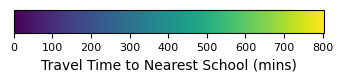

In [10]:
# INTERACTIVE MAP FOR SECONDARY SCHOOLS

# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_combined_routes_secondary_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------
# Primary/Secondary toggle
school_gdf = secondary_school_gdf
route_gdf = secondary_pop_routes_gdf
students = "secondary_school_students"

# Create layers for car, foot and boat
# Define helper function
def create_layer_gdfs(mode):
    gdf = route_gdf[route_gdf["travel_mode"]==mode]
    gdf_route = gdf_route = gpd.GeoDataFrame(gdf.copy(), geometry="geometry", crs="EPSG:4326")
    gdf_pop = gpd.GeoDataFrame(
        gdf[["pop_id",students,"pop_x","pop_y","school_id","school_name","travel_mode","time_min","dist_km"]], 
        geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")
    
    return gdf_route, gdf_pop

car_gdf_route, car_gdf_pop = create_layer_gdfs("car") # create layers for car
foot_gdf_route, foot_gdf_pop = create_layer_gdfs("foot") # create layers for foot
boat_gdf_route, boat_gdf_pop = create_layer_gdfs("boat") # create layers for boat

# Create layer for no routes
gdf = route_gdf[route_gdf["travel_mode"]=="no_route"]
no_route_gdf_pop = gpd.GeoDataFrame(
    gdf[["pop_id",students,"pop_x","pop_y"]], 
    geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")

# Create layer for all time for all population points
combined_pop_gdf = gpd.GeoDataFrame(
    route_gdf[["pop_id",students,"pop_x","pop_y","travel_mode","time_min"]], 
    geometry=gpd.points_from_xy(route_gdf["pop_x"], route_gdf["pop_y"]), crs="EPSG:4326")

# -----------------------------
# 2. Build viridis colour scale & line color based on combined mode
# -----------------------------

# Viridis colour scale based on osrm_min
vmin = combined_pop_gdf["time_min"].min()
vmax = combined_pop_gdf["time_min"].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("viridis")

def to_hex(v):
    rgba = cmap(norm(v))
    return mcolors.to_hex(rgba)

combined_pop_gdf["colour"] = combined_pop_gdf["time_min"].apply(to_hex)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (combined_pop_gdf["pop_x"].max() + combined_pop_gdf["pop_x"].min()) / 2
y = (combined_pop_gdf["pop_y"].max() + combined_pop_gdf["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=True)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Plain)",
    attribution="Esri World Imagery",
    visible=False
)

# -----------------------------
# 4. Create Population and Route Data Layers
# -----------------------------

# Car routes
m.add_gdf(
    gdf=car_gdf_route,
    name="Car Routes",
    layer_type="line",
    paint={"line-color": "#000000eb", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=car_gdf_pop,
    name="Car Population Points",
    layer_type="circle",
    paint={"circle-color": "#000000eb", "circle-radius" : 3},
    visible=True
)

# Boat routes
m.add_gdf(
    gdf=boat_gdf_route,
    name="Boat Routes",
    layer_type="line",
    paint={"line-color": "#00318DFF", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=boat_gdf_pop,
    name="Boat Population Points",
    layer_type="circle",
    paint={"circle-color": "#00318DFF", "circle-radius" : 3},
    visible=True
)

# Foot routes
m.add_gdf(
    gdf=foot_gdf_route,
    name="Foot Routes",
    layer_type="line",
    paint={"line-color": "#6200ffeb", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=foot_gdf_pop,
    name="Foot Population Points",
    layer_type="circle",
    paint={"circle-color": "#6200ffeb", "circle-radius" : 3},
    visible=True
)

# Points with no routes
m.add_gdf(
    gdf=no_route_gdf_pop,
    name="No Route Population Points",
    layer_type="circle",
    paint={"circle-color": "#ff0000eb", "circle-radius" : 3},
    visible=True
)

# Combined population points for the viridis time map
m.add_gdf(
    gdf=combined_pop_gdf,
    name="Travel Time",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": ["get", "colour"]},
    visible=False
)


# -----------------------------
# 5. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 6. Add school layers
# -----------------------------

# -- Secondary Schools ---
image_sec = "Interactive Maps/assets/icons/college_orange.png"

secondary_geojson = json.loads(secondary_school_gdf.to_json())
source_sec = {"type": "geojson", "data": secondary_geojson}

layer_sec = {
    "id": "Secondary Schools",
    "type": "symbol",
    "source": "point_sec",
    "layout": {
        "icon-image": "sec_school",
        "icon-size": 0.08}
}

m.add_image("sec_school", image_sec)
m.add_source("point_sec", source_sec)
m.add_layer(layer_sec)
m.add_popup("Secondary Schools")

# -----------------------------
# 7. Generate static colour bar PNG & Add to map
# -----------------------------

colorbar_path = os.path.join(assets_folder, "total_time_colorbar_sec.png")

common.save_colorbar(out_fig=colorbar_path,
                     label="Travel Time to Nearest School (mins)",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")

html = f'<img src="{colorbar_path}">'
m.add_html(html, position="bottom-right")

# -----------------------------
# 8. Add legend
# -----------------------------

legend_dict = {
    "car": "#000000eb",   # black
    "foot": "#6200ffeb",  # purple
    "boat": "#00318DFF",   # blue
    "no route": "#ff0000eb" # red
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = legend_dict,
    position = "bottom-right"
)

# -----------------------------
# 9. Add map title / sources
# -----------------------------

m.add_text(
    "Routes Taken to Nearest Secondary School",
    position="top-left",
    font_size=12
)

# -----------------------------
# 10. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Travel Time",
        "Secondary Schools",
        "Car Routes",
        "Car Population Points",
        "Foot Routes",
        "Foot Population Points",
        "Boat Routes",
        "Boat Population Points",
        "No Route Population Points",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery",
        "Esri.WorldImagery (Plain)"
    ],
    position="top-left"
)

# -----------------------------
# 11. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Time Taken to Nearest Secondary School in Sarawak",
    overwrite=True
)

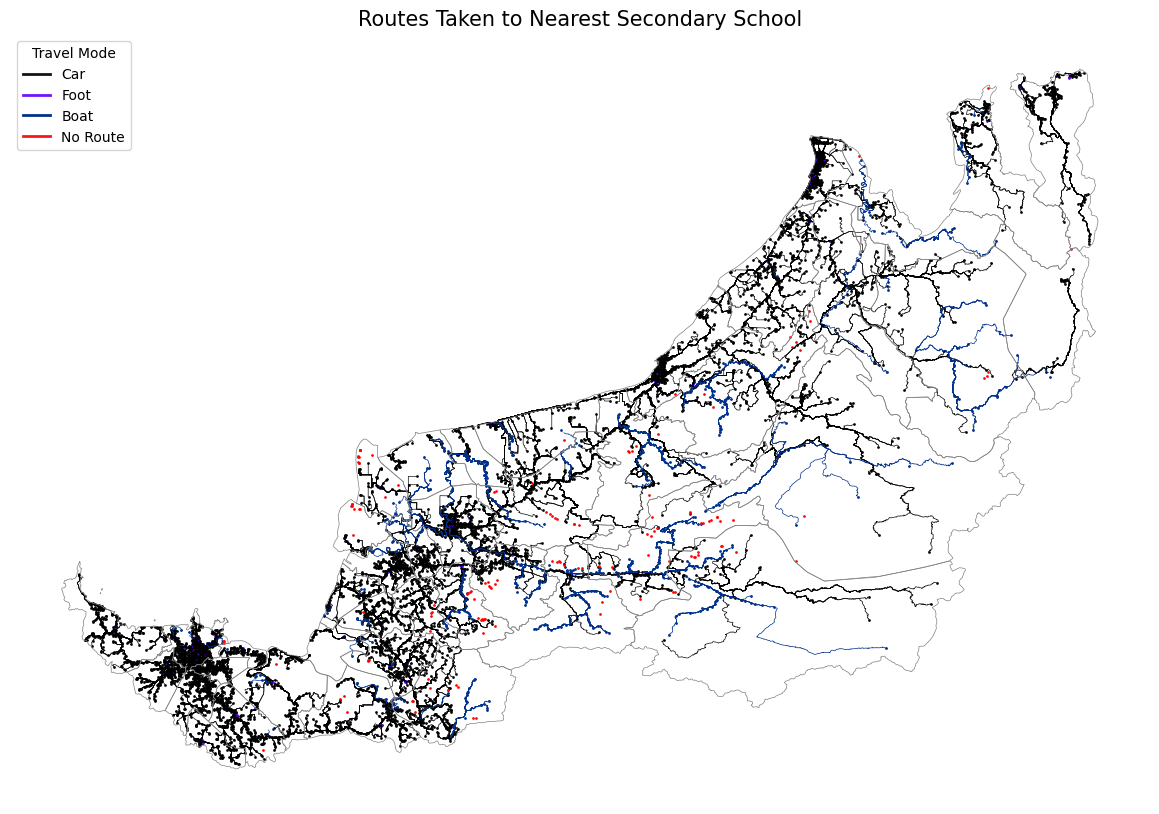

In [11]:
# STATIC MAP FOR SECONDARY SCHOOLS

# Set up plot
plt.figure(figsize=(16, 10))

# Plot car routes
car_gdf_route.plot(ax=plt.gca(), color="#000000eb", linewidth=0.5, label="Car Routes")
car_gdf_pop.plot(ax=plt.gca(), color="#000000eb", markersize=1, label="Car Population Points")

# Plot foot routes
foot_gdf_route.plot(ax=plt.gca(), color="#6200ffeb", linewidth=0.5, label="Foot Routes")
foot_gdf_pop.plot(ax=plt.gca(), color="#6200ffeb", markersize=1, label="Foot Population Points")

# Plot boat routes
boat_gdf_route.plot(ax=plt.gca(), color="#00318DFF", linewidth=0.5, label="Boat Routes")
boat_gdf_pop.plot(ax=plt.gca(), color="#00318DFF", markersize=1, label="Boat Population Points")

# Plot no route points
no_route_gdf_pop.plot(ax=plt.gca(), color="#ff0000eb", markersize=1, label="No Route Population Points")

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), color="grey", linewidth=0.5, label="District Boundaries")

# ---- Add custom legend ----
legend_dict = {
    "Car": "#000000eb",      # black
    "Foot": "#6200ffeb",     # purple
    "Boat": "#00318DFF",     # blue
    "No Route": "#ff0000eb"  # red
}

# Create custom legend elements
legend_handles = [
    Line2D([0], [0], color=color, linewidth=2, label=label)
    for label, color in legend_dict.items()
]

# Add legend to current axes
plt.legend(handles=legend_handles, title="Travel Mode", loc="upper left")

# ---- Remaining stuff ----
plt.title(f"Routes Taken to Nearest Secondary School", fontsize=15)
plt.axis("off")
plt.show()

Create interactive map of Primary School routes

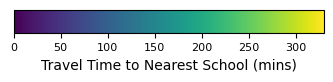

In [12]:
# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_combined_routes_primary_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------
# Primary/Secondary toggle
school_gdf = primary_school_gdf
route_gdf = primary_pop_routes_gdf
students = "primary_school_students"

# Create layers for car, foot and boat
# Define helper function
def create_layer_gdfs(mode):
    gdf = route_gdf[route_gdf["travel_mode"]==mode]
    gdf_route = gdf_route = gpd.GeoDataFrame(gdf.copy(), geometry="geometry", crs="EPSG:4326")
    gdf_pop = gpd.GeoDataFrame(
        gdf[["pop_id",students,"pop_x","pop_y","school_id","school_name","travel_mode","time_min","dist_km"]], 
        geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")
    
    return gdf_route, gdf_pop

car_gdf_route, car_gdf_pop = create_layer_gdfs("car") # create layers for car
foot_gdf_route, foot_gdf_pop = create_layer_gdfs("foot") # create layers for foot
boat_gdf_route, boat_gdf_pop = create_layer_gdfs("boat") # create layers for boat

# Create layer for no routes
gdf = route_gdf[route_gdf["travel_mode"]=="no_route"]
no_route_gdf_pop = gpd.GeoDataFrame(
    gdf[["pop_id",students,"pop_x","pop_y"]], 
    geometry=gpd.points_from_xy(gdf["pop_x"], gdf["pop_y"]), crs="EPSG:4326")

# Create layer for all time for all population points
combined_pop_gdf = gpd.GeoDataFrame(
    route_gdf[["pop_id",students,"pop_x","pop_y","travel_mode","time_min"]], 
    geometry=gpd.points_from_xy(route_gdf["pop_x"], route_gdf["pop_y"]), crs="EPSG:4326")

# -----------------------------
# 2. Build viridis colour scale & line color based on combined mode
# -----------------------------

# Viridis colour scale based on osrm_min
vmin = combined_pop_gdf["time_min"].min()
vmax = combined_pop_gdf["time_min"].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("viridis")

def to_hex(v):
    rgba = cmap(norm(v))
    return mcolors.to_hex(rgba)

combined_pop_gdf["colour"] = combined_pop_gdf["time_min"].apply(to_hex)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (combined_pop_gdf["pop_x"].max() + combined_pop_gdf["pop_x"].min()) / 2
y = (combined_pop_gdf["pop_y"].max() + combined_pop_gdf["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=True)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Plain)",
    attribution="Esri World Imagery",
    visible=False
)

# -----------------------------
# 4. Create Population and Route Data Layers
# -----------------------------

# Car routes
m.add_gdf(
    gdf=car_gdf_route,
    name="Car Routes",
    layer_type="line",
    paint={"line-color": "#000000eb", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=car_gdf_pop,
    name="Car Population Points",
    layer_type="circle",
    paint={"circle-color": "#000000eb", "circle-radius" : 3},
    visible=True
)

# Boat routes
m.add_gdf(
    gdf=boat_gdf_route,
    name="Boat Routes",
    layer_type="line",
    paint={"line-color": "#00318DFF", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=boat_gdf_pop,
    name="Boat Population Points",
    layer_type="circle",
    paint={"circle-color": "#00318DFF", "circle-radius" : 3},
    visible=True
)

# Foot routes
m.add_gdf(
    gdf=foot_gdf_route,
    name="Foot Routes",
    layer_type="line",
    paint={"line-color": "#6200ffeb", "line-width": 1},
    visible=True
)

m.add_gdf(
    gdf=foot_gdf_pop,
    name="Foot Population Points",
    layer_type="circle",
    paint={"circle-color": "#6200ffeb", "circle-radius" : 3},
    visible=True
)

# Points with no routes
m.add_gdf(
    gdf=no_route_gdf_pop,
    name="No Route Population Points",
    layer_type="circle",
    paint={"circle-color": "#ff0000eb", "circle-radius" : 3},
    visible=True
)

# Combined population points for the viridis time map
m.add_gdf(
    gdf=combined_pop_gdf,
    name="Travel Time",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": ["get", "colour"]},
    visible=False
)


# -----------------------------
# 5. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 6. Add school layers
# -----------------------------

# -- Primary Schools ---
image_pri = "Interactive Maps/assets/icons/college_blue.png"

primary_geojson = json.loads(primary_school_gdf.to_json())
source_pri = {"type": "geojson", "data": primary_geojson}

layer_pri = {
    "id": "Primary Schools",
    "type": "symbol",
    "source": "point_pri",
    "layout": {
        "icon-image": "pri_school",
        "icon-size": 0.08}
}

m.add_image("pri_school", image_pri)
m.add_source("point_pri", source_pri)
m.add_layer(layer_pri)
m.add_popup("Primary Schools")

# -----------------------------
# 7. Generate static colour bar PNG & Add to map
# -----------------------------

colorbar_path = os.path.join(assets_folder, "total_time_colorbar_pri.png")

common.save_colorbar(out_fig=colorbar_path,
                     label="Travel Time to Nearest School (mins)",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")

html = f'<img src="{colorbar_path}">'
m.add_html(html, position="bottom-right")

# -----------------------------
# 8. Add legend
# -----------------------------

legend_dict = {
    "car": "#000000eb",   # black
    "foot": "#6200ffeb",  # purple
    "boat": "#00318DFF",   # blue
    "no route": "#ff0000eb" # red
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = legend_dict,
    position = "bottom-right"
)

# -----------------------------
# 6. Add map title / sources
# -----------------------------

m.add_text(
    "Routes Taken to Nearest Primary School",
    position="top-left",
    font_size=12
)

# -----------------------------
# 8. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Travel Time",
        "Primary Schools",
        "Car Routes",
        "Car Population Points",
        "Foot Routes",
        "Foot Population Points",
        "Boat Routes",
        "Boat Population Points",
        "No Route Population Points",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery",
        "Esri.WorldImagery (Plain)"
    ],
    position="top-left"
)

# -----------------------------
# 9. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Time Taken to Nearest Primary School in Sarawak",
    overwrite=True
)

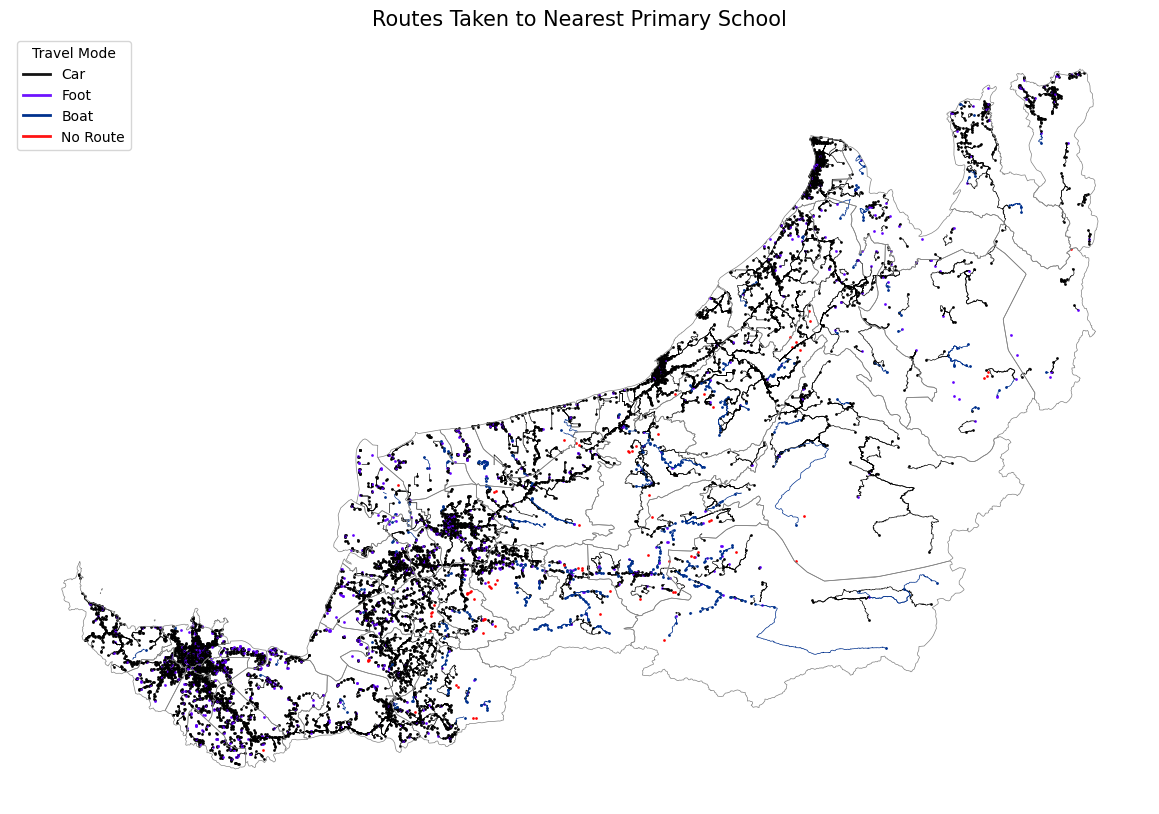

In [13]:
# STATIC MAP FOR PRIMARY SCHOOLS

# Set up plot
plt.figure(figsize=(16, 10))

# Plot car routes
car_gdf_route.plot(ax=plt.gca(), color="#000000eb", linewidth=0.5, label="Car Routes")
car_gdf_pop.plot(ax=plt.gca(), color="#000000eb", markersize=1, label="Car Population Points")

# Plot foot routes
foot_gdf_route.plot(ax=plt.gca(), color="#6200ffeb", linewidth=0.5, label="Foot Routes")
foot_gdf_pop.plot(ax=plt.gca(), color="#6200ffeb", markersize=1, label="Foot Population Points")

# Plot boat routes
boat_gdf_route.plot(ax=plt.gca(), color="#00318DFF", linewidth=0.5, label="Boat Routes")
boat_gdf_pop.plot(ax=plt.gca(), color="#00318DFF", markersize=1, label="Boat Population Points")

# Plot no route points
no_route_gdf_pop.plot(ax=plt.gca(), color="#ff0000eb", markersize=1, label="No Route Population Points")

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), color="grey", linewidth=0.5, label="District Boundaries")

# ---- Add custom legend ----
legend_dict = {
    "Car": "#000000eb",      # black
    "Foot": "#6200ffeb",     # purple
    "Boat": "#00318DFF",     # blue
    "No Route": "#ff0000eb"  # red
}

# Create custom legend elements
legend_handles = [
    Line2D([0], [0], color=color, linewidth=2, label=label)
    for label, color in legend_dict.items()
]

# Add legend to current axes
plt.legend(handles=legend_handles, title="Travel Mode", loc="upper left")

# ---- Remaining stuff ----
plt.title(f"Routes Taken to Nearest Primary School", fontsize=15)
plt.axis("off")
plt.show()